**[1. Importing Liabraries](https://)**

In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

**[2. File Reading](https://)**

In [71]:
df = pd.read_csv(r"C:\Users\ELASAD\Downloads\Telecom_Network_Data.csv")

**[3. Data Exploring](https://)**

In [72]:
df.head()

,timestamp,tower_id,users_connected,download_speed,upload_speed,latency,weather,congestion
0,2025-01-01 00:00:00,1,152,80.671584,9.988305,158.141290,Clear,0
1,2025-01-01 01:00:00,1,171,19.819479,3.846097,174.573468,Clear,0
2,2025-01-01 02:00:00,1,713,66.834405,3.764167,147.179767,Snow,0
3,2025-01-01 03:00:00,1,435,22.273372,9.986821,67.806026,Clear,0
4,2025-01-01 04:00:00,1,797,7.190930,26.713958,85.973585,Clear,0


In [73]:
df.shape

(3605, 8)

In [74]:
df.describe()

,tower_id,users_connected,download_speed,upload_speed,latency,congestion
count,3605.00000,3605.000000,3605.000000,3605.000000,3605.000000,3605.000000
mean,3.00000,531.091817,52.087743,25.167230,105.100378,0.056311
std,1.41441,275.722937,27.343304,13.995801,54.884409,0.230553
min,1.00000,50.000000,5.002918,1.054885,10.033348,0.000000
25%,2.00000,294.000000,28.481601,13.380487,58.075005,0.000000
50%,3.00000,538.000000,52.514068,25.104473,105.184167,0.000000
75%,4.00000,765.000000,75.252828,37.011367,153.865933,0.000000
max,5.00000,999.000000,99.985678,49.991019,199.952797,1.000000


In [75]:
df.columns

Index(['timestamp', 'tower_id', 'users_connected', 'download_speed',
       'upload_speed', 'latency', 'weather', 'congestion'],
      dtype='str')

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3605 entries, 0 to 3604
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        3605 non-null   str    
 1   tower_id         3605 non-null   int64  
 2   users_connected  3605 non-null   int64  
 3   download_speed   3605 non-null   float64
 4   upload_speed     3605 non-null   float64
 5   latency          3605 non-null   float64
 6   weather          3605 non-null   str    
 7   congestion       3605 non-null   int64  
dtypes: float64(3), int64(3), str(2)
memory usage: 225.4 KB


In [77]:
df.isnull().sum()

timestamp          0
tower_id           0
users_connected    0
download_speed     0
upload_speed       0
latency            0
weather            0
congestion         0
dtype: int64

In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
# Checking outliers using IQR method
numeric_cols = ["download_speed", "upload_speed", "latency", "users_connected"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers found")

download_speed: 0 outliers found
upload_speed: 0 outliers found
latency: 0 outliers found
users_connected: 0 outliers found


**[4. Data Cleaning](https://)**

In [80]:
# 1. transform timestamp data type form object to datetime

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"].dtype

dtype('<M8[us]')

**[5. Business Questions](https://)**

Main Question : What factors have the greatest impact on telecom network performance?

In [81]:
# Question 1. Does weather condition affect network performance?

df["weather"].value_counts()
df.groupby("weather")[["download_speed", "upload_speed", "latency"]].mean()

,download_speed,upload_speed,latency
weather,,,
Clear,52.055283,25.114998,103.870435
Rain,52.955555,25.015923,107.812863
Snow,50.682590,26.245802,109.713459
Storm,52.586536,24.331603,105.598250


**Q1 Finding :** Weather has a weak impact on network performance. Download speed, upload speed, and latency show only small differences across weather conditions.

**Conclusion :** Weather does not appear to be a major factor affecting network performance in this dataset.

In [82]:
# Qustion 2. Does the number of connected users affect network performance?

df[["users_connected", "download_speed"]].corr().round(2)

,users_connected,download_speed
users_connected,1.00,0.02
download_speed,0.02,1.00


**Q2 Finding :** The correlation between connected users and download speed is very close to zero (0.02)

**Conclusion :** The number of connected users does not show a significant linear relationship with download speed performance in this dataset.

In [83]:
# Questions 3. What time periods have the worst network performance?

df["hour"] = df["timestamp"].dt.hour
df[["timestamp", "hour"]].head()
hourly_performance = df.groupby("hour")[["download_speed", "upload_speed", "latency"]].mean()
hourly_performance.round(2)

print("Worst Download Speed Hour:", hourly_performance["download_speed"].idxmin())
print("Worst Upload Speed Hour:", hourly_performance["upload_speed"].idxmin())
print("Worst Latency Hour:", hourly_performance["latency"].idxmax())

print("Download Speed:", hourly_performance["download_speed"].min())
print("Upload Speed:", hourly_performance["upload_speed"].min())
print("Latency:", hourly_performance["latency"].max())

Worst Download Speed Hour: 9
Worst Upload Speed Hour: 22
Worst Latency Hour: 14
Download Speed: 46.140134845492476
Upload Speed: 22.911129444983136
Latency: 112.96104690186488


**Q3 Finding :** Network performance varies throughout the day. Download speed reaches its lowest value at 09:00 (46.14 Mbps), upload speed reaches its lowest at 22:00 (22.91 Mbps), while latency reaches its highest at 14:00 (112.96 ms).

**Conclusion:** There is no single worst hour across all performance metrics; the worst performance varies depending on the metric.

In [84]:
# Question 4. What time periods have the best network performance?

print("Best Download Speed Hour:", hourly_performance["download_speed"].idxmax())
print("Best Upload Speed Hour:", hourly_performance["upload_speed"].idxmax())
print("Best Latency Hour:", hourly_performance["latency"].idxmin())

print("Download Speed:", hourly_performance["download_speed"].max())
print("Upload Speed:", hourly_performance["upload_speed"].max())
print("Latency:", hourly_performance["latency"].min())

Best Download Speed Hour: 18
Best Upload Speed Hour: 15
Best Latency Hour: 8
Download Speed: 58.13585746862198
Upload Speed: 27.04068093129741
Latency: 96.16060804712836


**Q4 Finding :** Network performance varies throughout the day. Download speed reaches its highest value at 18:00 (58.14 Mbps), upload speed reaches its highest at 15:00 (27.04 Mbps), while latency reaches its lowest value at 08:00 (96.16 ms).

**Conclusion:** There is no single best hour across all performance metrics; the best time period varies depending on the metric.

In [85]:
# Question 5. Is there a relationship between download speed and upload speed?

correlation = df["download_speed"].corr(df["upload_speed"])
print("Correlation:", round(correlation, 2))

Correlation: -0.02


**Finding :** The correlation between download speed and upload speed is -0.02, which is very close to zero.

**Conclusion :** There is no clear linear relationship between download speed and upload speed in this dataset.

In [86]:
# Question 6. Does network congestion affect network performance?

df[["congestion", "download_speed", "upload_speed", "latency"]].corr().round(2)

,congestion,download_speed,upload_speed,latency
congestion,1.00,0.00,-0.01,0.31
download_speed,0.00,1.00,-0.02,0.02
upload_speed,-0.01,-0.02,1.00,0.00
latency,0.31,0.02,0.00,1.00


**Finding :** Congestion shows almost no linear relationship with download speed or upload speed (correlation ≈ 0.00 and -0.01). However, it shows a moderate positive correlation with latency (0.31), meaning higher congestion is associated with higher latency.

**Conclusion :** Congestion is the first factor in the analysis to show a clear linear effect — but that effect is on latency, not on download or upload speed.

**[6. Visuals](https://)**

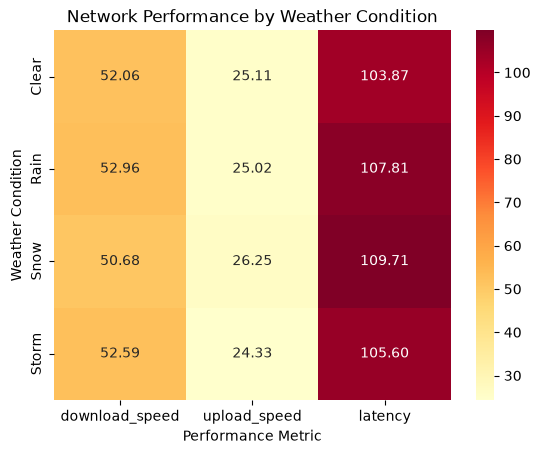

In [87]:
# Q1. Heatmap Visual

weather_performance = df.groupby("weather")[["download_speed", "upload_speed", "latency"]].mean()

sns.heatmap(weather_performance,annot=True,fmt=".2f",cmap="YlOrRd")

plt.title("Network Performance by Weather Condition")
plt.xlabel("Performance Metric")
plt.ylabel("Weather Condition")
plt.show()

**Q1 Insight :** Network performance shows only minor differences across weather conditions. Download speed, upload speed, and latency remain relatively similar, indicating that weather has a weak impact on overall network performance.


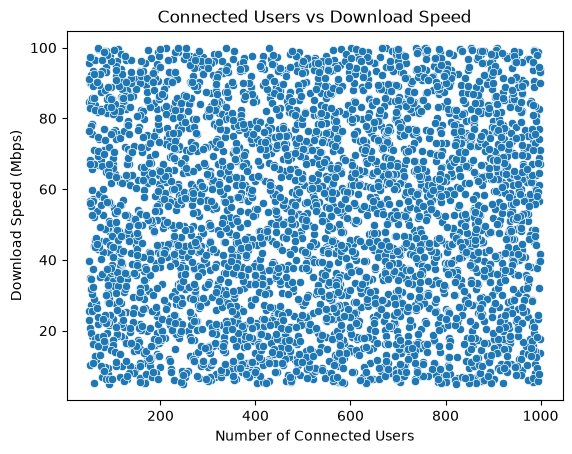

In [88]:
# Q2. Scatter Plot

sns.scatterplot(data=df,x="users_connected",y="download_speed")
plt.title("Connected Users vs Download Speed")
plt.xlabel("Number of Connected Users")
plt.ylabel("Download Speed (Mbps)")
plt.show()

**Q2 Insight :** The scatter plot shows no clear relationship between the number of connected users and network performance. Correlations with download speed (0.02) very weak.


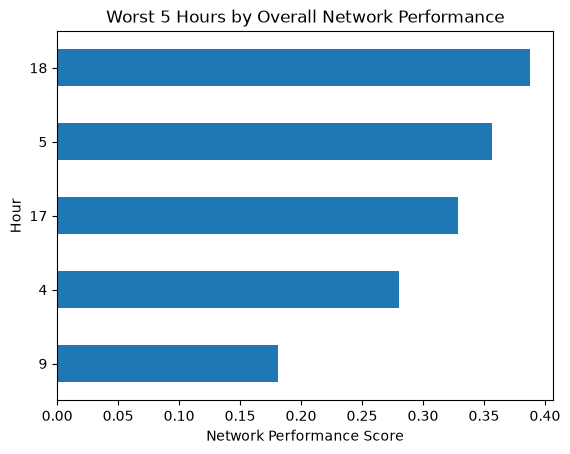

In [89]:
# Q3. Horizontal Bar Chart

# Normalize performance metrics
scaler = MinMaxScaler()
performance = scaler.fit_transform(hourly_performance[["download_speed", "upload_speed", "latency"]])
performance_df = pd.DataFrame(performance,columns=["download_score", "upload_score", "latency_score"],index=hourly_performance.index)

# Higher speed is better, lower latency is better
performance_df["network_score"] = (performance_df["download_score"]+ performance_df["upload_score"]+ (1 - performance_df["latency_score"])) / 3

# Worst 5 hours
worst_5 = performance_df["network_score"].nsmallest(5)

# Visualization
worst_5.sort_values().plot(kind="barh")
plt.title("Worst 5 Hours by Overall Network Performance")
plt.xlabel("Network Performance Score")
plt.ylabel("Hour")
plt.show()

**Q3 Insight :** The Network Performance Score combines download speed, upload speed, and latency into a single score. A **lower score indicates worse overall network performance**. The chart highlights the 5 hours with the lowest scores, representing the worst-performing periods of the day.


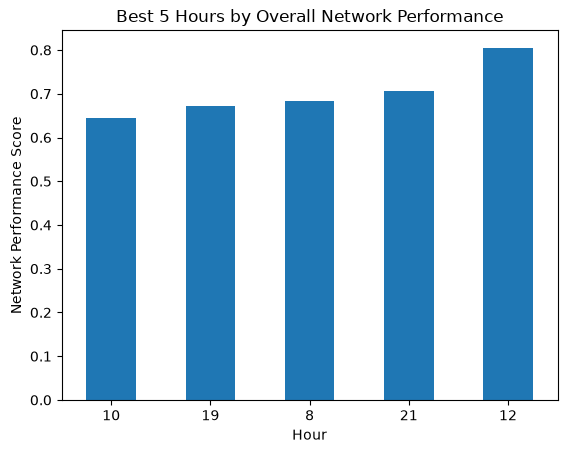

In [90]:
# Q4. Vertical Bar Chart

# Best 5 hours
best_5 = performance_df["network_score"].nlargest(5).sort_values()

# Final Visualization
best_5.plot(kind="bar")
plt.title("Best 5 Hours by Overall Network Performance")
plt.xlabel("Hour")
plt.ylabel("Network Performance Score")
plt.xticks(rotation=0)
plt.show()

**Q4 Insight :** The Network Performance Score combines download speed, upload speed, and latency into a single score. A **higher score indicates better overall network performance**. The chart highlights the 5 hours with the highest scores, representing the best-performing periods of the day.


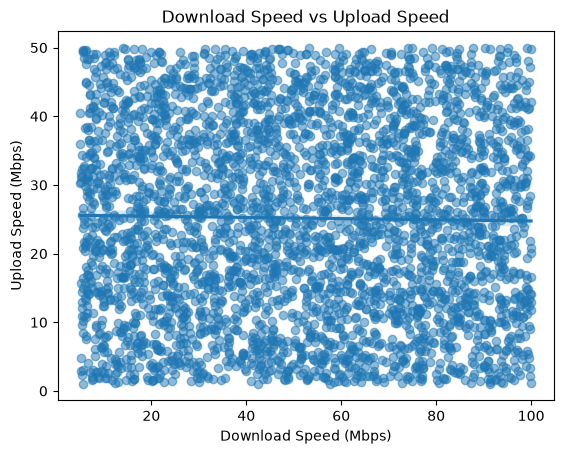

In [91]:
# Q5. Scatter Plot + Trendline

sns.regplot(data=df,x="download_speed",y="upload_speed",scatter_kws={"alpha": 0.5},line_kws={})
plt.title("Download Speed vs Upload Speed")
plt.xlabel("Download Speed (Mbps)")
plt.ylabel("Upload Speed (Mbps)")
plt.show()

**Q5 Insight :** The scatter plot shows no clear linear relationship between download speed and upload speed. The correlation of -0.02 indicates that changes in download speed are not meaningfully associated with changes in upload speed.


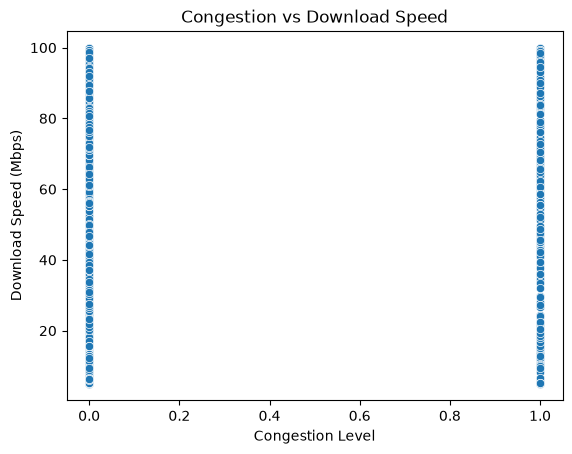

In [92]:
# Q6.
sns.scatterplot(data=df, x="congestion", y="download_speed")
plt.title("Congestion vs Download Speed")
plt.xlabel("Congestion Level")
plt.ylabel("Download Speed (Mbps)")
plt.show()

**Q6 Insight :** The scatter plot shows no clear relationship between congestion and download speed. Correlation (0.00) confirms this factor has no significant effect on download speed.

**[7. Machine learning](https://)**

Can we predict network download speed based on network conditions?

In [93]:
# Importing Liabraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [94]:
# Selecting Features and Target
X = df[["users_connected", "upload_speed","latency","weather","congestion","hour"]]
Y = df["download_speed"]

In [95]:
# Splitting the Data
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [96]:
categorical_features = ["weather"]
# Encoding Categorical Data
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [97]:
# Apply Encoding
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [98]:
# Training the Model
LR = LinearRegression()
LR.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.4 , 0.65,-0.68,..., 0. ,-0.78, 0.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,49.66
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[14835.34, 2946.27, 750.18,..., 12.9 , 10.93, 0. ]"


In [99]:
# Making Predictions
Y_pred = LR.predict(X_test)

In [100]:
# Model Evaluation
MAE = mean_absolute_error(Y_test, Y_pred)
RMSE = mean_squared_error(Y_test, Y_pred) ** 0.5
R2 = r2_score(Y_test, Y_pred)

print("MAE:", MAE)
print("RMSE:", RMSE)
print("R2 Score:", R2)

MAE: 23.552737532796172
RMSE: 27.42278110910501
R2 Score: 0.001102817565301839


**Finding:** The Linear Regression model showed weak prediction performance for download_speed, with an R² Score close to zero.

**Conclusion:** the selected features were not sufficient for accurately predicting download speed using this model.

**Overall Conclusion:**
After analyzing the different factors affecting network performance (weather, connected users, time of day, and congestion), most factors showed a very weak linear relationship with download speed and upload speed individually.

Time of day (hour) was the only factor that showed a clear and noticeable variation in performance throughout the day, while weather, connected users, and congestion did not show a strong linear effect on speed.

The one clear exception was congestion, which showed a moderate positive correlation (0.31) with latency — meaning higher congestion is associated with higher delay, even though it did not affect download or upload speed directly.

This was also reflected in the Linear Regression model's weak performance (R² close to zero) in predicting download speed from the available features, which supports the conclusion that no single factor strongly and directly controls network speed — congestion's main effect appears to be on latency rather than speed.